<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Tokenization/Tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load dataset
import csv
df = pd.read_csv("/content/Remove punctuation and special characters.csv", on_bad_lines='skip', engine='python')



# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62961 entries, 0 to 62960
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        62961 non-null  object
 1   comment_text              62961 non-null  object
 2   toxic                     62961 non-null  int64 
 3   comment_length            62961 non-null  int64 
 4   word_count                62961 non-null  int64 
 5   punctuation_count         62961 non-null  int64 
 6   comment_text_processed    62961 non-null  object
 7   comment_length_processed  62961 non-null  int64 
 8   word_count_processed      62961 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 4.3+ MB
None

First 5 Rows:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  explanation\nwhy the edits made under my usern...      0   
1  000103f0d9cfb60f  d'aww! he matches this backgro


Before Tokenization Dataset Summary:
         char_count    word_count
count  62961.000000  62961.000000
mean     397.438954     67.795334
std      597.641714    100.480505
min        5.000000      1.000000
25%       96.000000     17.000000
50%      206.000000     36.000000
75%      437.000000     75.000000
max     5000.000000   1403.000000


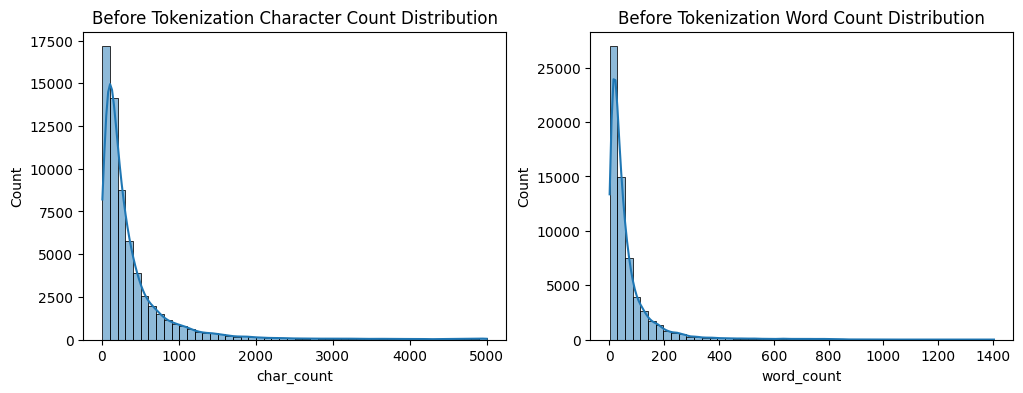

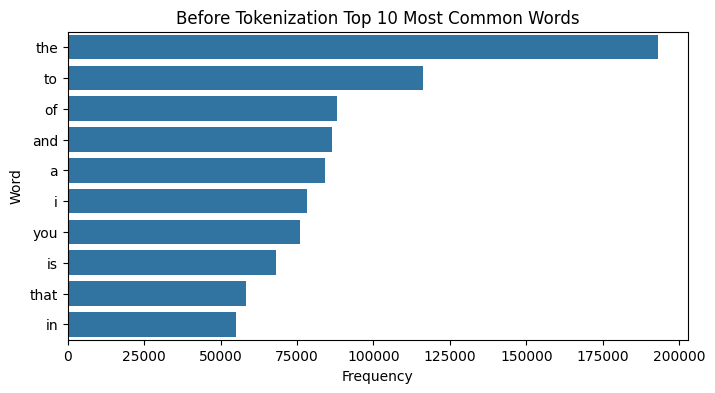

In [2]:
# ----- EDA Function for Raw Text -----
def text_eda(data, column_name, title_prefix=""):
    # Text length features
    data["char_count"] = data[column_name].apply(lambda x: len(str(x)))
    data["word_count"] = data[column_name].apply(lambda x: len(str(x).split()))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary:")
    print(data[[column_name, "char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common words
    all_words = " ".join(data[column_name].astype(str)).split()
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Words")
    plt.show()

# ----- EDA Before Tokenization -----
text_eda(df.copy(), "comment_text", title_prefix="Before Tokenization")


In [3]:
# ----- Preprocessing (Tokenization) -----
df_tokenized = df.copy()
df_tokenized["tokens"] = df_tokenized["comment_text"].apply(lambda x: str(x).split())
print("✅ Data has been preprocessed: text has been tokenized into word lists.")

✅ Data has been preprocessed: text has been tokenized into word lists.



After Tokenization Dataset Summary (Tokenized):
         char_count    word_count
count  62961.000000  62961.000000
mean     327.431362     67.795334
std      494.494627    100.480505
min        5.000000      1.000000
25%       79.000000     17.000000
50%      169.000000     36.000000
75%      359.000000     75.000000
max     4965.000000   1403.000000


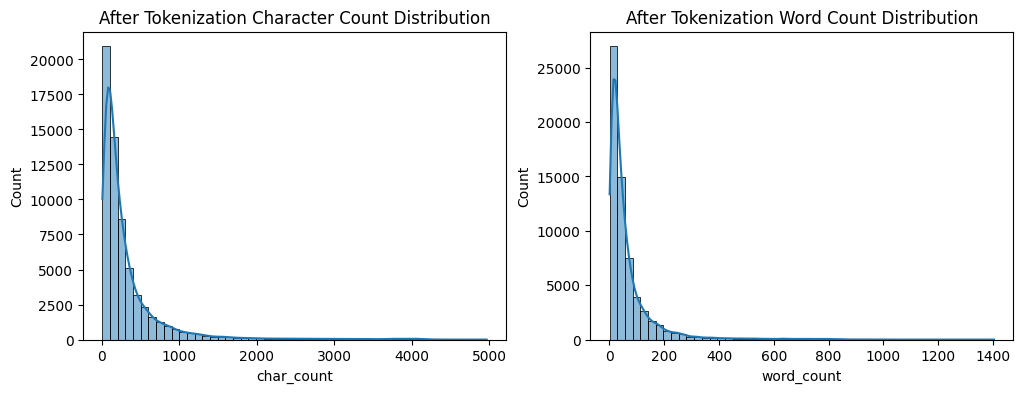

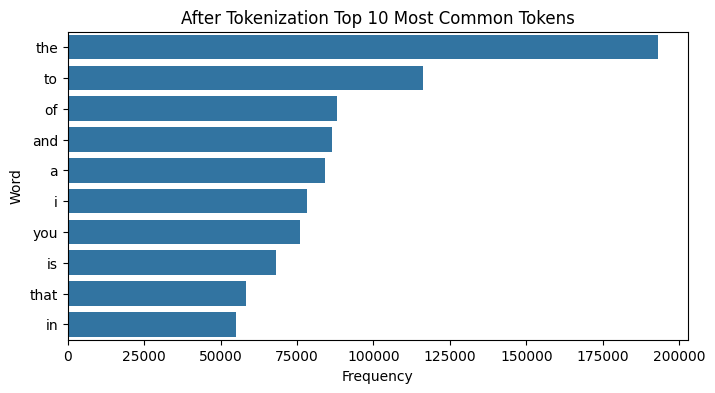

In [4]:
# ----- EDA Function for Tokenized Data -----
def token_eda(data, column_name, title_prefix=""):
    # Word count per comment
    data["word_count"] = data[column_name].apply(len)
    data["char_count"] = data[column_name].apply(lambda x: sum(len(w) for w in x))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary (Tokenized):")
    print(data[[column_name, "char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common tokens
    all_words = [w for tokens in data[column_name] for w in tokens]
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Tokens")
    plt.show()

# ----- EDA After Tokenization -----
token_eda(df_tokenized.copy(), "tokens", title_prefix="After Tokenization")



In [5]:
# ----- Save Tokenized Dataset -----
df_tokenized.to_csv("train_tokenized.csv", index=False)
print("💾 Tokenized dataset saved as train_tokenized.csv")

💾 Tokenized dataset saved as train_tokenized.csv


/tmp/ipython-input-1159554854.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Freq", y="Word", data=words_df, ax=axes[0], palette="Blues_d")
/tmp/ipython-input-1159554854.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Freq", y="Token", data=tokens_df, ax=axes[1], palette="Greens_d")


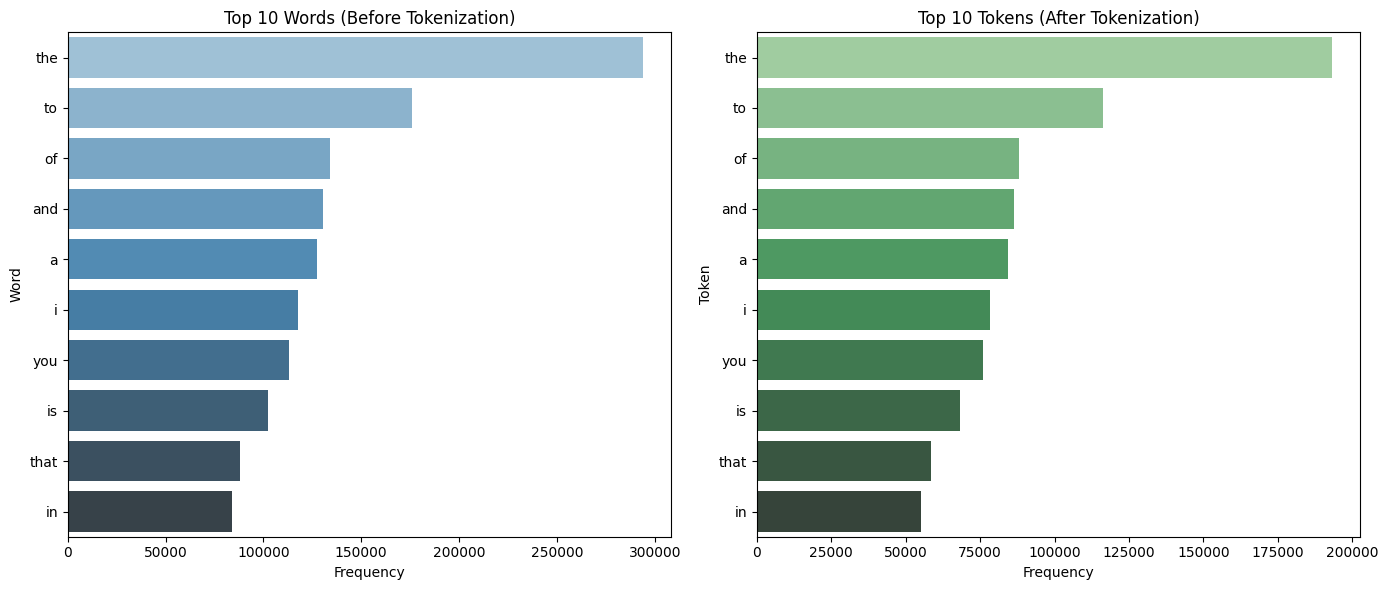

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# ----- Prepare Top Words and Tokens -----
top_n = 10

# Top words before tokenization
df = pd.read_csv("/content/Remove punctuation and special characters.csv", on_bad_lines='skip', engine='python')

words_before = " ".join(df["comment_text"].astype(str)).split()
common_words = Counter(words_before).most_common(top_n)
words_df = pd.DataFrame(common_words, columns=["Word", "Freq"])

# Top tokens after tokenization
tokens_after = [token for tokens in df_tokenized["tokens"] for token in tokens]
common_tokens = Counter(tokens_after).most_common(top_n)
tokens_df = pd.DataFrame(common_tokens, columns=["Token", "Freq"])

# ----- Plot Side by Side -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before tokenization
sns.barplot(x="Freq", y="Word", data=words_df, ax=axes[0], palette="Blues_d")
axes[0].set_title("Top 10 Words (Before Tokenization)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

# After tokenization
sns.barplot(x="Freq", y="Token", data=tokens_df, ax=axes[1], palette="Greens_d")
axes[1].set_title("Top 10 Tokens (After Tokenization)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()
